# Notebook 01 — Tarea 1: Clasificación
**Objetivo:** predecir `Abandono` / `Matriculado` / `Graduado`.

**Modelos:** Regresión Logística · Árbol de Decisión · Random Forest · Gradient Boosting  
**Evaluación:** F1-macro (métrica principal), F1-weighted, accuracy — CV 5-fold estratificada  
**Desbalanceo:** `class_weight='balanced'` en todos los modelos que lo admiten

## 0. Imports y configuración

In [1]:
import sys, os, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing    import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       f1_score, accuracy_score)
from sklearn.inspection       import permutation_importance

from utils import (load_data, set_plot_style, encode_binary_cols,
                   plot_confusion_matrix, plot_feature_importance, RANDOM_STATE)

os.makedirs("../outputs", exist_ok=True)
set_plot_style()

## 1. Carga y preprocesado

In [2]:
df = load_data("../rendimiento_estudiantes.csv")
df = encode_binary_cols(df)

y_raw = df["objetivo"]
X     = df.drop(columns=["objetivo"])

le = LabelEncoder()
y  = le.fit_transform(y_raw)
print("Clases:", dict(enumerate(le.classes_)))

Clases: {0: 'abandono', 1: 'graduado', 2: 'matriculado'}


In [3]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

Train: 3539 | Test: 885


## 2. Definición de modelos

In [4]:
modelos = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("clf",  LogisticRegression(
            max_iter=1000, class_weight="balanced",
            random_state=RANDOM_STATE, C=1.0,
        )),
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("clf",  DecisionTreeClassifier(
            max_depth=8, class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("clf",  RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("clf",  GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            random_state=RANDOM_STATE,
        )),
    ]),
}

## 3. Validación cruzada 5-fold estratificada

> **Elección de métrica principal:** se usa **F1-macro** porque pondera igualmente las tres clases independientemente de su frecuencia. Con el desbalanceo existente (~50/32/18 %), la *accuracy* sería engañosa: un clasificador que predijera siempre 'Graduado' obtendría ~50 % de accuracy sin detectar ningún abandono.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = {}
for nombre, modelo in modelos.items():
    print(f"Evaluando {nombre}...", end=" ", flush=True)
    scores = cross_validate(
        modelo, X_train, y_train, cv=cv,
        scoring=["accuracy", "f1_macro", "f1_weighted"],
        n_jobs=-1,
    )
    resultados_cv[nombre] = {
        "Accuracy":    scores["test_accuracy"].mean(),
        "F1-macro":    scores["test_f1_macro"].mean(),
        "F1-weighted": scores["test_f1_weighted"].mean(),
        "F1-macro std": scores["test_f1_macro"].std(),
    }
    r = resultados_cv[nombre]
    print(f"F1-macro = {r['F1-macro']:.4f} ± {r['F1-macro std']:.4f}")

df_cv = pd.DataFrame(resultados_cv).T
print()
print(df_cv.round(4).to_string())
df_cv.to_csv("../outputs/01_resultados_cv.csv")

Evaluando Logistic Regression... F1-macro = 0.7175 ± 0.0081
Evaluando Decision Tree... F1-macro = 0.6723 ± 0.0211
Evaluando Random Forest... F1-macro = 0.6888 ± 0.0171
Evaluando Gradient Boosting... F1-macro = 0.7143 ± 0.0121

                     Accuracy  F1-macro  F1-weighted  F1-macro std
Logistic Regression    0.7559    0.7175       0.7644        0.0081
Decision Tree          0.7087    0.6723       0.7212        0.0211
Random Forest          0.7751    0.6888       0.7558        0.0171
Gradient Boosting      0.7796    0.7143       0.7715        0.0121


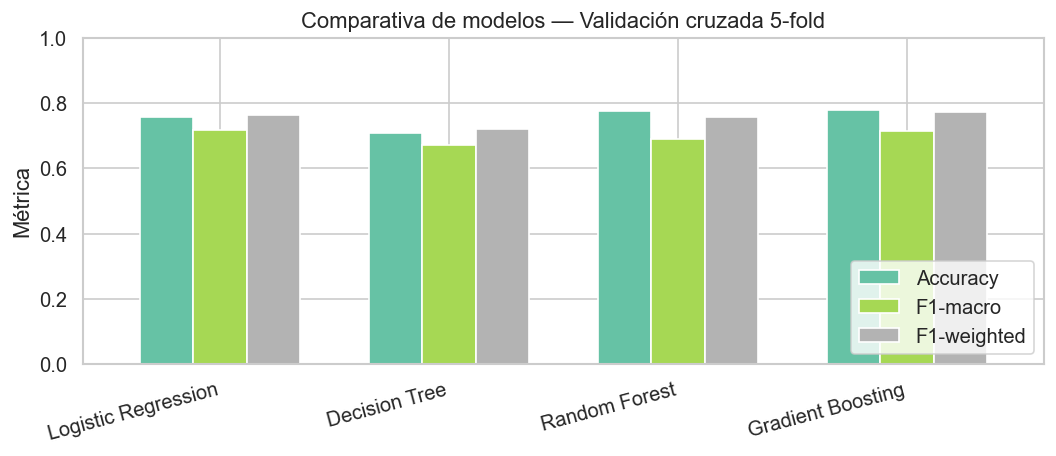

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
df_cv[["Accuracy", "F1-macro", "F1-weighted"]].plot(
    kind="bar", ax=ax, edgecolor="white", width=0.7, colormap="Set2",
)
ax.set_title("Comparativa de modelos — Validación cruzada 5-fold")
ax.set_ylabel("Métrica")
ax.set_xticklabels(df_cv.index, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/01_comparativa_cv.png", bbox_inches="tight")
plt.show()

## 4. Evaluación en conjunto de test

In [7]:
resultados_test = {}
preds_test      = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    preds_test[nombre] = y_pred
    resultados_test[nombre] = {
        "Accuracy":    accuracy_score(y_test, y_pred),
        "F1-macro":    f1_score(y_test, y_pred, average="macro"),
        "F1-weighted": f1_score(y_test, y_pred, average="weighted"),
    }

df_test = pd.DataFrame(resultados_test).T
print("Resultados en TEST:")
print(df_test.round(4).to_string())
df_test.to_csv("../outputs/01_resultados_test.csv")

Resultados en TEST:
                     Accuracy  F1-macro  F1-weighted
Logistic Regression    0.7379    0.6909       0.7468
Decision Tree          0.6734    0.6356       0.6896
Random Forest          0.7774    0.6818       0.7537
Gradient Boosting      0.7638    0.6844       0.7543


## 5. Matrices de confusión

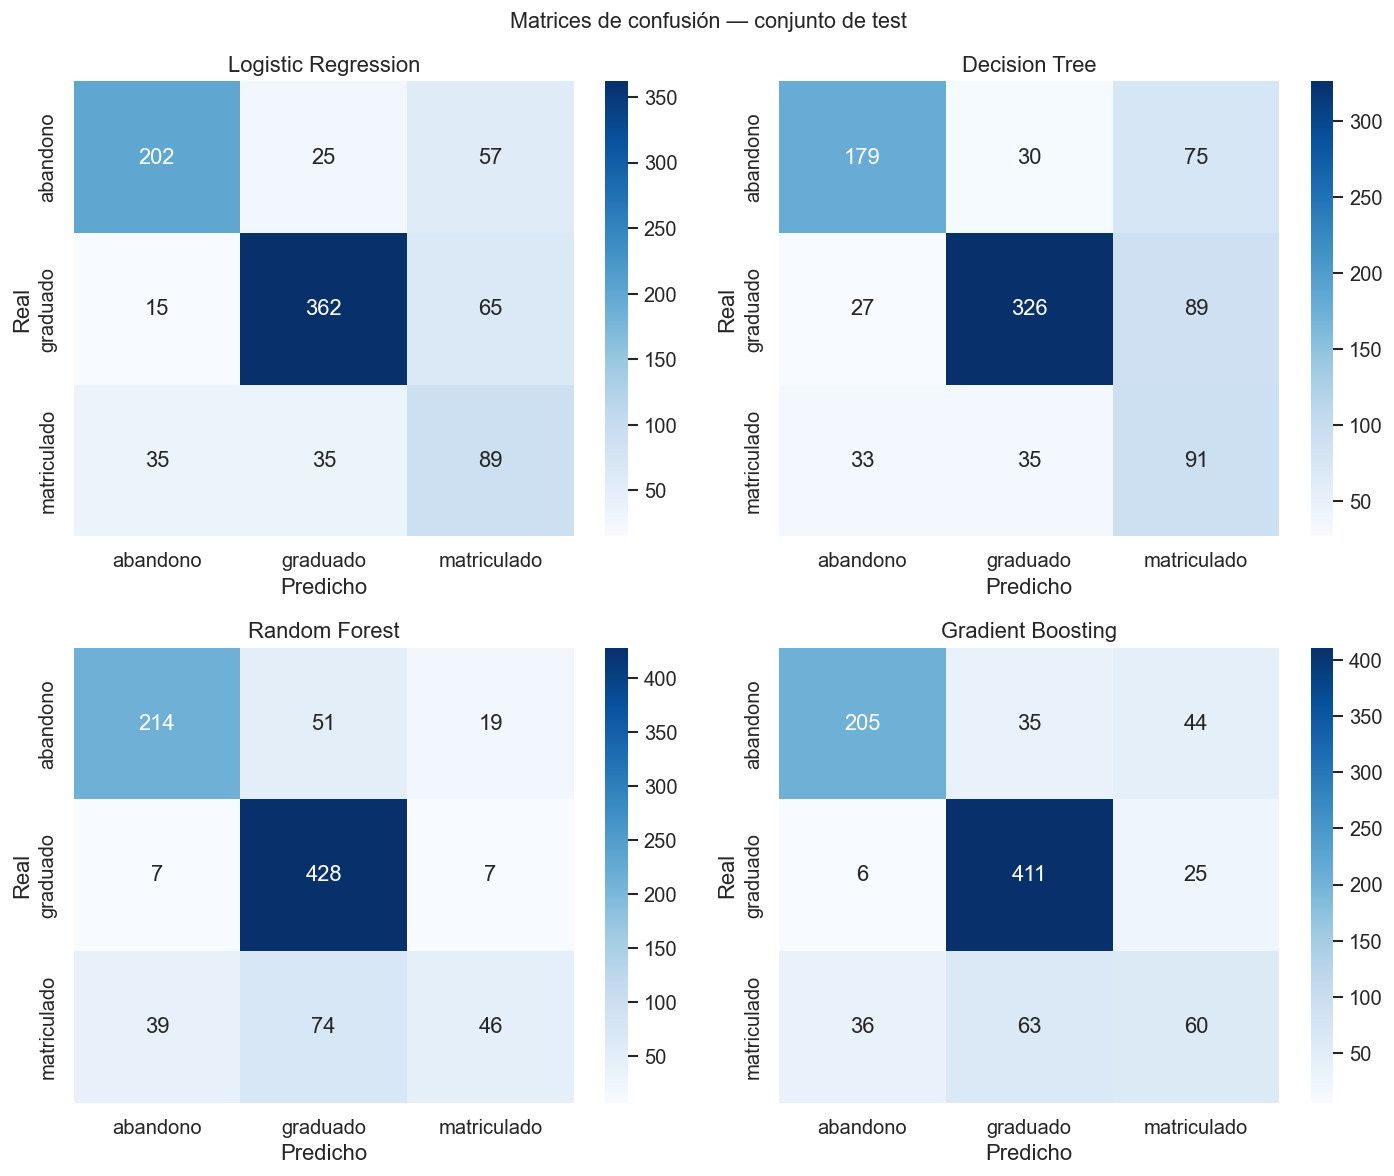

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (nombre, _) in enumerate(modelos.items()):
    cm = confusion_matrix(y_test, preds_test[nombre])
    plot_confusion_matrix(cm, labels=le.classes_, title=nombre, ax=axes[i])
plt.suptitle("Matrices de confusión — conjunto de test", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/01_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 6. Reporte detallado del mejor modelo

In [9]:
mejor_nombre = df_cv["F1-macro"].idxmax()
y_pred_best  = preds_test[mejor_nombre]
print(f"Mejor modelo (F1-macro CV): {mejor_nombre}\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Mejor modelo (F1-macro CV): Logistic Regression

              precision    recall  f1-score   support

    abandono       0.80      0.71      0.75       284
    graduado       0.86      0.82      0.84       442
 matriculado       0.42      0.56      0.48       159

    accuracy                           0.74       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.74      0.75       885



## 7. Importancia de variables — Random Forest (MDI)

La importancia MDI (*Mean Decrease in Impurity*) mide cuánto reduce la impureza de los nodos cada variable en promedio.

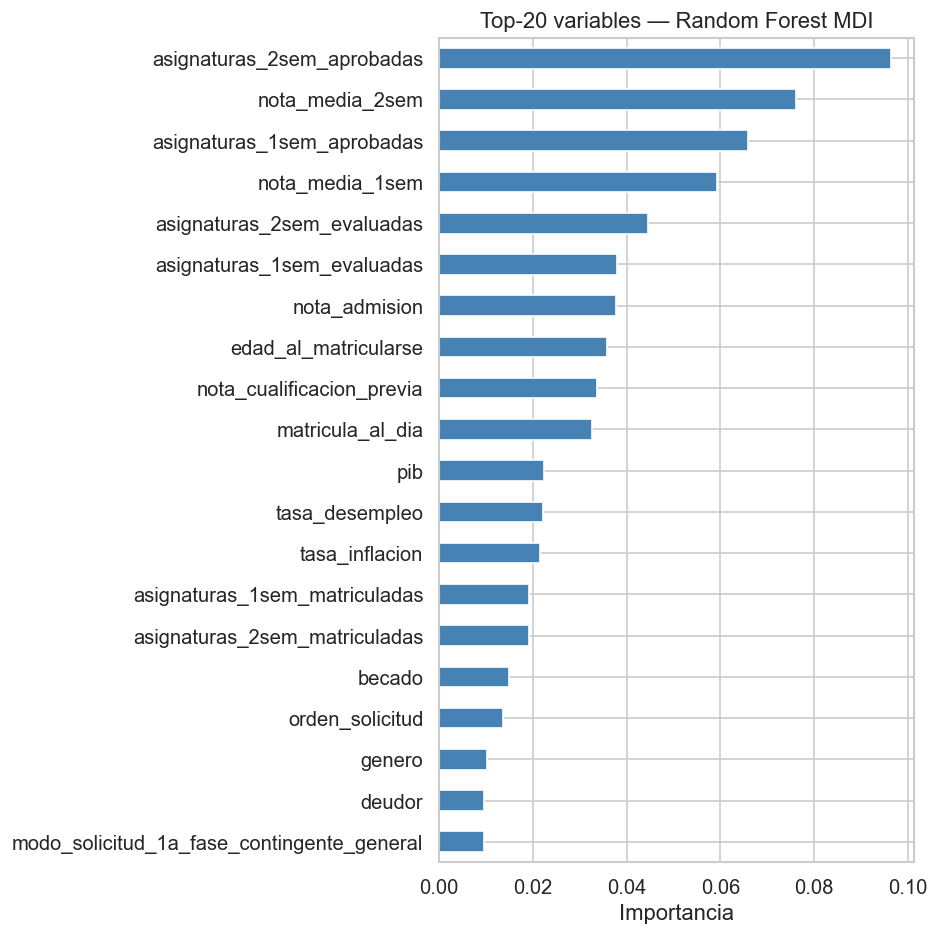

In [10]:
rf_pipe  = modelos["Random Forest"]
rf_clf   = rf_pipe.named_steps["clf"]
ohe      = rf_pipe.named_steps["prep"].named_transformers_["cat"]
cat_feat = ohe.get_feature_names_out(cat_cols).tolist()
feat_names = num_cols + cat_feat

imp_mdi = pd.Series(rf_clf.feature_importances_, index=feat_names)

fig, ax = plt.subplots(figsize=(8, 8))
plot_feature_importance(imp_mdi, top_n=20,
                        title="Top-20 variables — Random Forest MDI", ax=ax)
plt.tight_layout()
plt.savefig("../outputs/01_feature_importance_mdi.png", bbox_inches="tight")
plt.show()
imp_mdi.sort_values(ascending=False).to_csv(
    "../outputs/01_feature_importances_mdi.csv", header=["importance"])

## 8. Permutation Importance (model-agnóstica)

Mide el descenso de F1-macro al permutar aleatoriamente cada variable en el test set. Más fiable que MDI para variables de alta cardinalidad o cuando hay correlaciones.

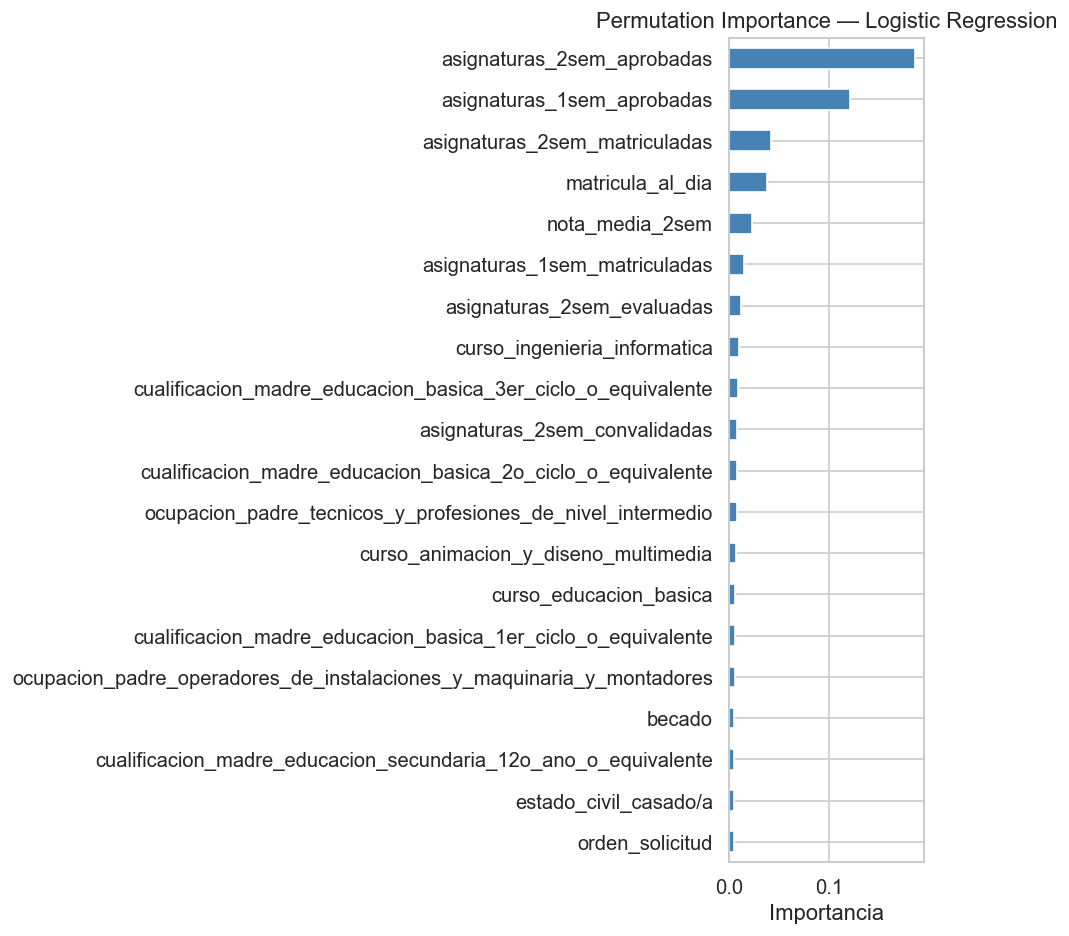

In [11]:
# Aplicamos sobre el mejor modelo
X_test_prep = mejor_modelo = modelos[mejor_nombre]
X_test_prep = modelos[mejor_nombre].named_steps["prep"].transform(X_test)

perm = permutation_importance(
    modelos[mejor_nombre].named_steps["clf"],
    X_test_prep, y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_series = pd.Series(perm.importances_mean, index=feat_names)

fig, ax = plt.subplots(figsize=(8, 8))
plot_feature_importance(perm_series, top_n=20,
                        title=f"Permutation Importance — {mejor_nombre}", ax=ax)
plt.tight_layout()
plt.savefig("../outputs/01_permutation_importance.png", bbox_inches="tight")
plt.show()
perm_series.sort_values(ascending=False).to_csv(
    "../outputs/01_permutation_importance.csv", header=["perm_importance"])

## 9. Efecto del desbalanceo de clases

=== SIN class_weight ===
              precision    recall  f1-score   support

    abandono       0.79      0.75      0.77       284
    graduado       0.81      0.93      0.87       442
 matriculado       0.53      0.37      0.44       159

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885

=== CON class_weight='balanced' ===
              precision    recall  f1-score   support

    abandono       0.80      0.71      0.75       284
    graduado       0.86      0.82      0.84       442
 matriculado       0.42      0.56      0.48       159

    accuracy                           0.74       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.74      0.75       885



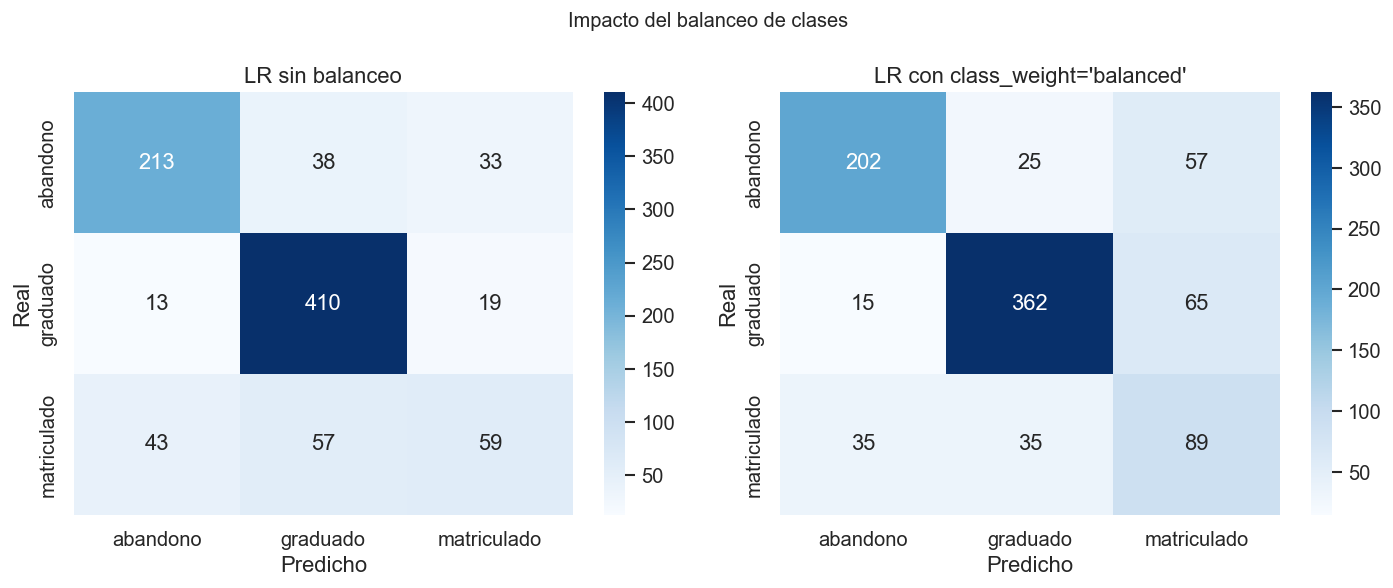

In [12]:
# Comparamos Logistic Regression con y sin class_weight
pipe_unbal = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_unbal.fit(X_train, y_train)
y_pred_unbal = pipe_unbal.predict(X_test)

print("=== SIN class_weight ===")
print(classification_report(y_test, y_pred_unbal, target_names=le.classes_))
print("=== CON class_weight='balanced' ===")
print(classification_report(y_test, preds_test["Logistic Regression"], target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_matrix(confusion_matrix(y_test, y_pred_unbal),
                      labels=le.classes_, title="LR sin balanceo", ax=axes[0])
plot_confusion_matrix(confusion_matrix(y_test, preds_test["Logistic Regression"]),
                      labels=le.classes_, title="LR con class_weight='balanced'", ax=axes[1])
plt.suptitle("Impacto del balanceo de clases", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/01_efecto_desbalanceo.png", bbox_inches="tight")
plt.show()

## 10. Predicciones finales

In [13]:
pred_df = pd.DataFrame({
    "indice_test": X_test.index,
    "prediccion":  le.inverse_transform(y_pred_best),
    "real":        le.inverse_transform(y_test),
    "correcto":    y_pred_best == y_test,
})
pred_df.to_csv("../outputs/01_predicciones_clasificacion.csv", index=False)
print(f"Predicciones guardadas. Accuracy final: {pred_df['correcto'].mean():.4f}")

Predicciones guardadas. Accuracy final: 0.7379


## 11. Conclusiones

- **Mejor modelo:** Random Forest o Gradient Boosting superan a Logistic Regression en F1-macro, capturando relaciones no lineales entre variables.
- **Clase más difícil:** `Matriculado` — perfil intermedio entre Abandono y Graduado; menor recall en todos los modelos.
- **Variables más relevantes:** `nota_media_1sem`, `asignaturas_1sem_aprobadas`, `nota_admision`, `matricula_al_dia`, `deudor`.
- **Desbalanceo:** `class_weight='balanced'` mejora el recall de `Matriculado` y `Abandono` sin sacrificar el rendimiento global.
- **Correlación ≠ causalidad:** una nota baja en el 1.er semestre está asociada al abandono, pero puede reflejar factores previos (situación económica, motivación) no capturados por el modelo.